# Sentiment Analysis Using Cardiff RoBERTa Model for LLM Responses

# Import Libraries

In [2]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
from transformers import pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy import stats
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
from itertools import combinations
import os

warnings.filterwarnings('ignore')

# 1: LOAD DATA

The Excel file has a flat structure with columns: `Model`, `Gender`, `Question`, `Response`.

In [4]:
def load_data(excel_file):
    """
    Load the Excel file with flat structure:
    Columns: Model, Gender, Question, Response
    Gender values: Neutral, Woman, Man
    Model values: GPT, Claude, Gemini, Grok, Deepseek
    """
    print("Loading data from Excel file...")

    df = pd.read_excel(excel_file)

    # Standardize column names (strip whitespace, handle case variations)
    df.columns = df.columns.str.strip()

    # Rename columns to internal standard names
    col_map = {}
    for col in df.columns:
        lower = col.lower()
        if lower == 'model':
            col_map[col] = 'LLM'
        elif lower == 'gender':
            col_map[col] = 'Gender'
        elif lower == 'question':
            col_map[col] = 'Scenario'
        elif lower == 'response':
            col_map[col] = 'Response'
    df = df.rename(columns=col_map)

    # Normalize gender labels to lowercase consistent values
    gender_map = {'Neutral': 'gender_neutral', 'Woman': 'woman', 'Man': 'man',
                  'neutral': 'gender_neutral', 'woman': 'woman', 'man': 'man',
                  'gender_neutral': 'gender_neutral'}
    df['Gender'] = df['Gender'].map(gender_map).fillna(df['Gender'])

    # Drop rows with missing responses
    df = df[df['Response'].notna()]
    df = df[df['Response'].astype(str).str.strip() != '']
    df = df.reset_index(drop=True)

    print(f"Total responses loaded: {len(df)}")
    print(f"LLMs: {sorted(df['LLM'].unique().tolist())}")
    print(f"Genders: {df['Gender'].unique().tolist()}")
    print(f"Scenarios (questions): {df['Scenario'].nunique()}")
    print(f"\nShape: {df.shape}")
    print("\nSample:")
    print(df.head(3).to_string())

    return df

In [5]:
# Set file path: Update this path to point to your Excel file.
# If running in the same directory as the file, just use the filename.
dataset_file = "C:\\Users\\Mariam Sulleiman\\LLM\\LLMprocessed_output.xlsx"

In [6]:
# Load data
df = load_data(dataset_file)

Loading data from Excel file...
Total responses loaded: 3150
LLMs: ['Claude', 'Deepseek', 'GPT', 'Gemini', 'Grok']
Genders: ['gender_neutral', 'woman', 'man']
Scenarios (questions): 21

Shape: (3150, 4)

Sample:
   LLM          Gender Scenario                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           Response
0  GPT  gender_neutral      Q_1  The user demonstrates solid proficiency across a range of makerspace tasks (woodworking from stock, drilling, turning on a lathe, sanding, finishing with epoxy) and shows plann

# 2: SENTIMENT ANALYSIS using Cardiff RoBERTa

## Initialize Model

In [7]:
def initialize_sentiment_model():
    """
    Load Cardiff NLP RoBERTa sentiment model (3-class: positive, neutral, negative).
    Automatically uses GPU if available.
    """
    print("\nLoading Cardiff NLP RoBERTa sentiment model...")
    print("(3-class: positive, neutral, negative)\n")

    device = 0 if torch.cuda.is_available() else -1
    model = pipeline(
        "sentiment-analysis",
        model="cardiffnlp/twitter-roberta-base-sentiment-latest",
        device=device,
        truncation=True,
        max_length=512
    )

    print(f"Model loaded successfully! (device: {'GPU' if device == 0 else 'CPU'})\n")
    return model

In [8]:
# Initialize model
sentiment_model = initialize_sentiment_model()


Loading Cardiff NLP RoBERTa sentiment model...
(3-class: positive, neutral, negative)



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully! (device: CPU)



## Run Sentiment Analysis

In [9]:
def analyze_sentiment_cardiff(df, model, batch_size=32):
    """
    Run Cardiff RoBERTa sentiment analysis on all responses.
    Uses batching for efficiency.
    Returns DataFrame with sentiment scores.
    """
    print("\nRunning sentiment analysis with Cardiff model...")
    print(f"Total responses to analyze: {len(df)}")
    print(f"Batch size: {batch_size}\n")

    texts = df['Response'].astype(str).tolist()

    # Truncate texts to 512 tokens (model limit)
    texts_truncated = [t[:1500] for t in texts]  # ~512 tokens in chars

    all_results = []
    for start in range(0, len(texts_truncated), batch_size):
        batch = texts_truncated[start:start + batch_size]
        batch_results = model(batch, truncation=True, max_length=512)
        all_results.extend(batch_results)
        if (start // batch_size) % 5 == 0:
            print(f"  Progress: {min(start + batch_size, len(texts))}/{len(texts)} responses...")

    # Build result dataframe
    records = []
    for i, (row_tuple, result) in enumerate(zip(df.itertuples(index=False), all_results)):
        label = result['label'].lower()
        score = result['score']

        # Convert to numerical score: positive = +score, negative = -score, neutral = 0
        if label == 'positive':
            numerical = score
        elif label == 'negative':
            numerical = -score
        else:
            numerical = 0.0

        # Coarse category
        if numerical > 0.05:
            category = 'positive'
        elif numerical < -0.05:
            category = 'negative'
        else:
            category = 'neutral'

        records.append({
            'LLM': row_tuple.LLM,
            'Scenario': row_tuple.Scenario,
            'Gender': row_tuple.Gender,
            'Response': texts[i],
            'cardiff_label': label,
            'cardiff_score': score,
            'cardiff_numerical': numerical,
            'sentiment_category': category
        })

    results_df = pd.DataFrame(records)

    print(f"\nCompleted! Analyzed {len(results_df)} responses.")
    print("\n" + "="*70)
    print("SENTIMENT ANALYSIS SUMMARY")
    print("="*70)

    print("\nSentiment Distribution:")
    print(results_df['sentiment_category'].value_counts())

    print("\nSentiment by Gender (mean ± std):")
    print(results_df.groupby('Gender')['cardiff_numerical']
          .agg(['count', 'mean', 'std']).round(4))

    print("\nSentiment by LLM (mean ± std):")
    print(results_df.groupby('LLM')['cardiff_numerical']
          .agg(['count', 'mean', 'std']).round(4))

    return results_df

In [10]:
# Run sentiment analysis
results_df = analyze_sentiment_cardiff(df, sentiment_model)


Running sentiment analysis with Cardiff model...
Total responses to analyze: 3150
Batch size: 32

  Progress: 32/3150 responses...
  Progress: 192/3150 responses...
  Progress: 352/3150 responses...
  Progress: 512/3150 responses...


KeyboardInterrupt: 

# 4: COSINE SIMILARITY ON ORIGINAL RESPONSES

For each LLM × Scenario, compare responses across the three gender conditions using TF-IDF vectorizer.

In [ ]:
def calculate_cosine_similarity_responses(df):
    """
    Compute pairwise cosine similarity between gender conditions
    (gender_neutral vs man, gender_neutral vs woman, man vs woman)
    within each LLM and Scenario group.

    Uses TF-IDF vectorization on the raw response text.
    """
    print("\nCalculating cosine similarity between gender conditions...")
    print(f"Unique LLMs:      {sorted(df['LLM'].unique())}")
    print(f"Unique Scenarios: {df['Scenario'].nunique()}")

    genders = ['gender_neutral', 'woman', 'man']
    pairs = list(combinations(genders, 2))

    records = []
    groups = df.groupby(['LLM', 'Scenario'])
    total = len(groups)

    for i, ((llm, scenario), group) in enumerate(groups):
        if i % 100 == 0:
            print(f"  Processing group {i}/{total}...")

        # Build a dict: gender - response text
        gender_text = {}
        for _, row in group.iterrows():
            g = row['Gender']
            if g in genders:
                gender_text[g] = str(row['Response'])

        # Need at least 2 genders to compare
        if len(gender_text) < 2:
            continue

        # Fit TF-IDF on all available texts for this group
        available_genders = [g for g in genders if g in gender_text]
        corpus = [gender_text[g] for g in available_genders]

        try:
            vectorizer = TfidfVectorizer(
                stop_words='english',
                min_df=1,
                ngram_range=(1, 2),
                sublinear_tf=True
            )
            tfidf_matrix = vectorizer.fit_transform(corpus)

            # Compute pairwise similarities
            sim_matrix = cosine_similarity(tfidf_matrix)
            gender_to_idx = {g: idx for idx, g in enumerate(available_genders)}

            for g1, g2 in pairs:
                if g1 in gender_to_idx and g2 in gender_to_idx:
                    idx1, idx2 = gender_to_idx[g1], gender_to_idx[g2]
                    sim = float(sim_matrix[idx1, idx2])

                    # Similarity label
                    if sim >= 0.8:    label = 'Very High'
                    elif sim >= 0.6:  label = 'High'
                    elif sim >= 0.4:  label = 'Moderate'
                    elif sim >= 0.2:  label = 'Low'
                    else:             label = 'Very Low'

                    records.append({
                        'LLM': llm,
                        'Scenario': scenario,
                        'Gender_1': g1,
                        'Gender_2': g2,
                        'Comparison': f"{g1} vs {g2}",
                        'Cosine_Similarity': sim,
                        'Similarity_Label': label
                    })
        except Exception as e:
            # Skip groups where vectorization fails (like empty texts)
            continue

    similarity_df = pd.DataFrame(records)

    print(f"\nTotal pairwise comparisons: {len(similarity_df)}")

    if len(similarity_df) > 0:
        print("COSINE SIMILARITY SUMMARY")

        print("\nMean Similarity by Comparison Type:")
        print(similarity_df.groupby('Comparison')['Cosine_Similarity']
              .agg(['count', 'mean', 'std', 'min', 'max']).round(4))

        print("\nMean Similarity by LLM:")
        print(similarity_df.groupby(['LLM', 'Comparison'])['Cosine_Similarity']
              .mean().unstack().round(4))

        print("\nSimilarity Labels Distribution:")
        print(pd.crosstab(similarity_df['Comparison'],
                          similarity_df['Similarity_Label'],
                          normalize='index').round(3) * 100)

        # Gender bias detection
        print("GENDER BIAS DETECTION (neutral vs man  vs  neutral vs woman)")

        for llm in sorted(similarity_df['LLM'].unique()):
            llm_sim = similarity_df[similarity_df['LLM'] == llm]
            nm = llm_sim[llm_sim['Comparison'] == 'gender_neutral vs man']['Cosine_Similarity'].mean()
            nw = llm_sim[llm_sim['Comparison'] == 'gender_neutral vs woman']['Cosine_Similarity'].mean()
            diff = nm - nw
            bias = " MALE BIAS" if diff > 0.01 else (" FEMALE BIAS" if diff < -0.01 else "to BALANCED")
            print(f"  {llm:10s}  neutral-man={nm:.4f}  neutral-woman={nw:.4f}  diff={diff:+.4f}  {bias}")

        # Overall
        nm_all = similarity_df[similarity_df['Comparison'] == 'gender_neutral vs man']['Cosine_Similarity'].mean()
        nw_all = similarity_df[similarity_df['Comparison'] == 'gender_neutral vs woman']['Cosine_Similarity'].mean()
        diff_all = nm_all - nw_all
        print(f"\n  OVERALL     neutral-man={nm_all:.4f}  neutral-woman={nw_all:.4f}  diff={diff_all:+.4f}")
        if diff_all > 0.01:
            print(f"  MALE BIAS: Neutral responses {diff_all*100:.2f}% more similar to male responses")
        elif diff_all < -0.01:
            print(f" FEMALE BIAS: Neutral responses {abs(diff_all)*100:.2f}% more similar to female responses")
        else:
            print(" NO SIGNIFICANT BIAS: Equal similarity to both genders")
    return similarity_df

In [ ]:
# Calculate cosine similarity
similarity_df = calculate_cosine_similarity_responses(df)


Calculating cosine similarity between gender conditions...
Unique LLMs:      ['Claude', 'Deepseek', 'GPT', 'Gemini', 'Grok']
Unique Scenarios: 21
  Processing group 0/105...
  Processing group 100/105...

Total pairwise comparisons: 315

COSINE SIMILARITY SUMMARY

Mean Similarity by Comparison Type:
                         count    mean     std     min     max
Comparison                                                    
gender_neutral vs man      105  0.1538  0.0768  0.0331  0.5266
gender_neutral vs woman    105  0.1570  0.0772  0.0310  0.3784
woman vs man               105  0.1532  0.0642  0.0262  0.3909

Mean Similarity by LLM:
Comparison  gender_neutral vs man  gender_neutral vs woman  woman vs man
LLM                                                                     
Claude                     0.1535                   0.1698        0.1840
Deepseek                   0.1773                   0.1676        0.1373
GPT                        0.1073                   0.1287        

# STEP 6: VISUALIZATION

In [ ]:
def create_visualizations(results_df, similarity_df):
    """
    Generate six plots covering sentiment and cosine similarity results.
    Saves two figure files.
    """
    print("\n\nCreating visualizations...")

    sns.set_style("whitegrid")
    GENDER_ORDER = ['gender_neutral', 'woman', 'man']
    PALETTE = {'gender_neutral': '#5b9bd5', 'woman': '#ed7d31', 'man': '#70ad47'}

    fig, axes = plt.subplots(3, 2, figsize=(16, 15))

    # Plot 1: Box plot – sentiment by gender
    ax1 = axes[0, 0]
    sns.boxplot(data=results_df, x='Gender', y='cardiff_numerical', ax=ax1,
                order=GENDER_ORDER, palette=PALETTE)
    ax1.set_title('Sentiment Distribution by Gender (All LLMs)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Gender Condition', fontsize=12)
    ax1.set_ylabel('Cardiff Sentiment Score (−1 to 1)', fontsize=12)
    ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)

    # Plot 2: Bar – mean sentiment by LLM × gender
    ax3 = axes[1, 0]
    pivot = results_df.pivot_table(
        values='cardiff_numerical', index='LLM', columns='Gender', aggfunc='mean'
    )
    # Reorder gender columns if present
    ordered_cols = [g for g in GENDER_ORDER if g in pivot.columns]
    pivot = pivot[ordered_cols]
    pivot.plot(kind='bar', ax=ax3, color=[PALETTE[g] for g in ordered_cols])
    ax3.set_title('Average Sentiment by LLM and Gender', fontsize=14, fontweight='bold')
    ax3.set_xlabel('LLM', fontsize=12)
    ax3.set_ylabel('Average Sentiment Score', fontsize=12)
    ax3.legend(title='Gender', loc='best')
    ax3.axhline(0, color='gray', linestyle='--', alpha=0.5)
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')



    # Plot : Cosine similarity by comparison
    ax5 = axes[2, 0]
    if len(similarity_df) > 0:
        comp_order = sorted(similarity_df['Comparison'].unique())
        sns.boxplot(data=similarity_df, x='Comparison', y='Cosine_Similarity',
                    order=comp_order, ax=ax5)
        ax5.set_title('Text Similarity Across Gender Conditions', fontsize=14, fontweight='bold')
        ax5.set_xlabel('Gender Comparison', fontsize=12)
        ax5.set_ylabel('Cosine Similarity', fontsize=12)
        plt.setp(ax5.xaxis.get_majorticklabels(), rotation=30, ha='right')
    else:
        ax5.text(0.5, 0.5, 'No similarity data', ha='center', va='center', transform=ax5.transAxes)



    # Figure 2: Per-LLM boxplots
    llms = sorted(results_df['LLM'].unique())
    n = len(llms)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig2, axes2 = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), squeeze=False)
    axes2_flat = axes2.flatten()

    for idx, llm in enumerate(llms):
        llm_data = results_df[results_df['LLM'] == llm]
        sns.boxplot(data=llm_data, x='Gender', y='cardiff_numerical',
                    order=GENDER_ORDER, palette=PALETTE, ax=axes2_flat[idx])
        axes2_flat[idx].set_title(llm, fontsize=13, fontweight='bold')
        axes2_flat[idx].set_xlabel('Gender', fontsize=11)
        axes2_flat[idx].set_ylabel('Sentiment Score', fontsize=11)
        axes2_flat[idx].axhline(0, color='gray', linestyle='--', alpha=0.5)

    for idx in range(n, len(axes2_flat)):
        axes2_flat[idx].axis('off')

    plt.tight_layout()
    plt.savefig('sentiment_by_llm.png', dpi=300, bbox_inches='tight')
    print("  Saved: sentiment_by_llm.png")
    print("\nVisualizations complete!")



Creating visualizations...
  Saved: sentiment_analysis_results.png
  Saved: sentiment_by_llm.png

Visualizations complete!


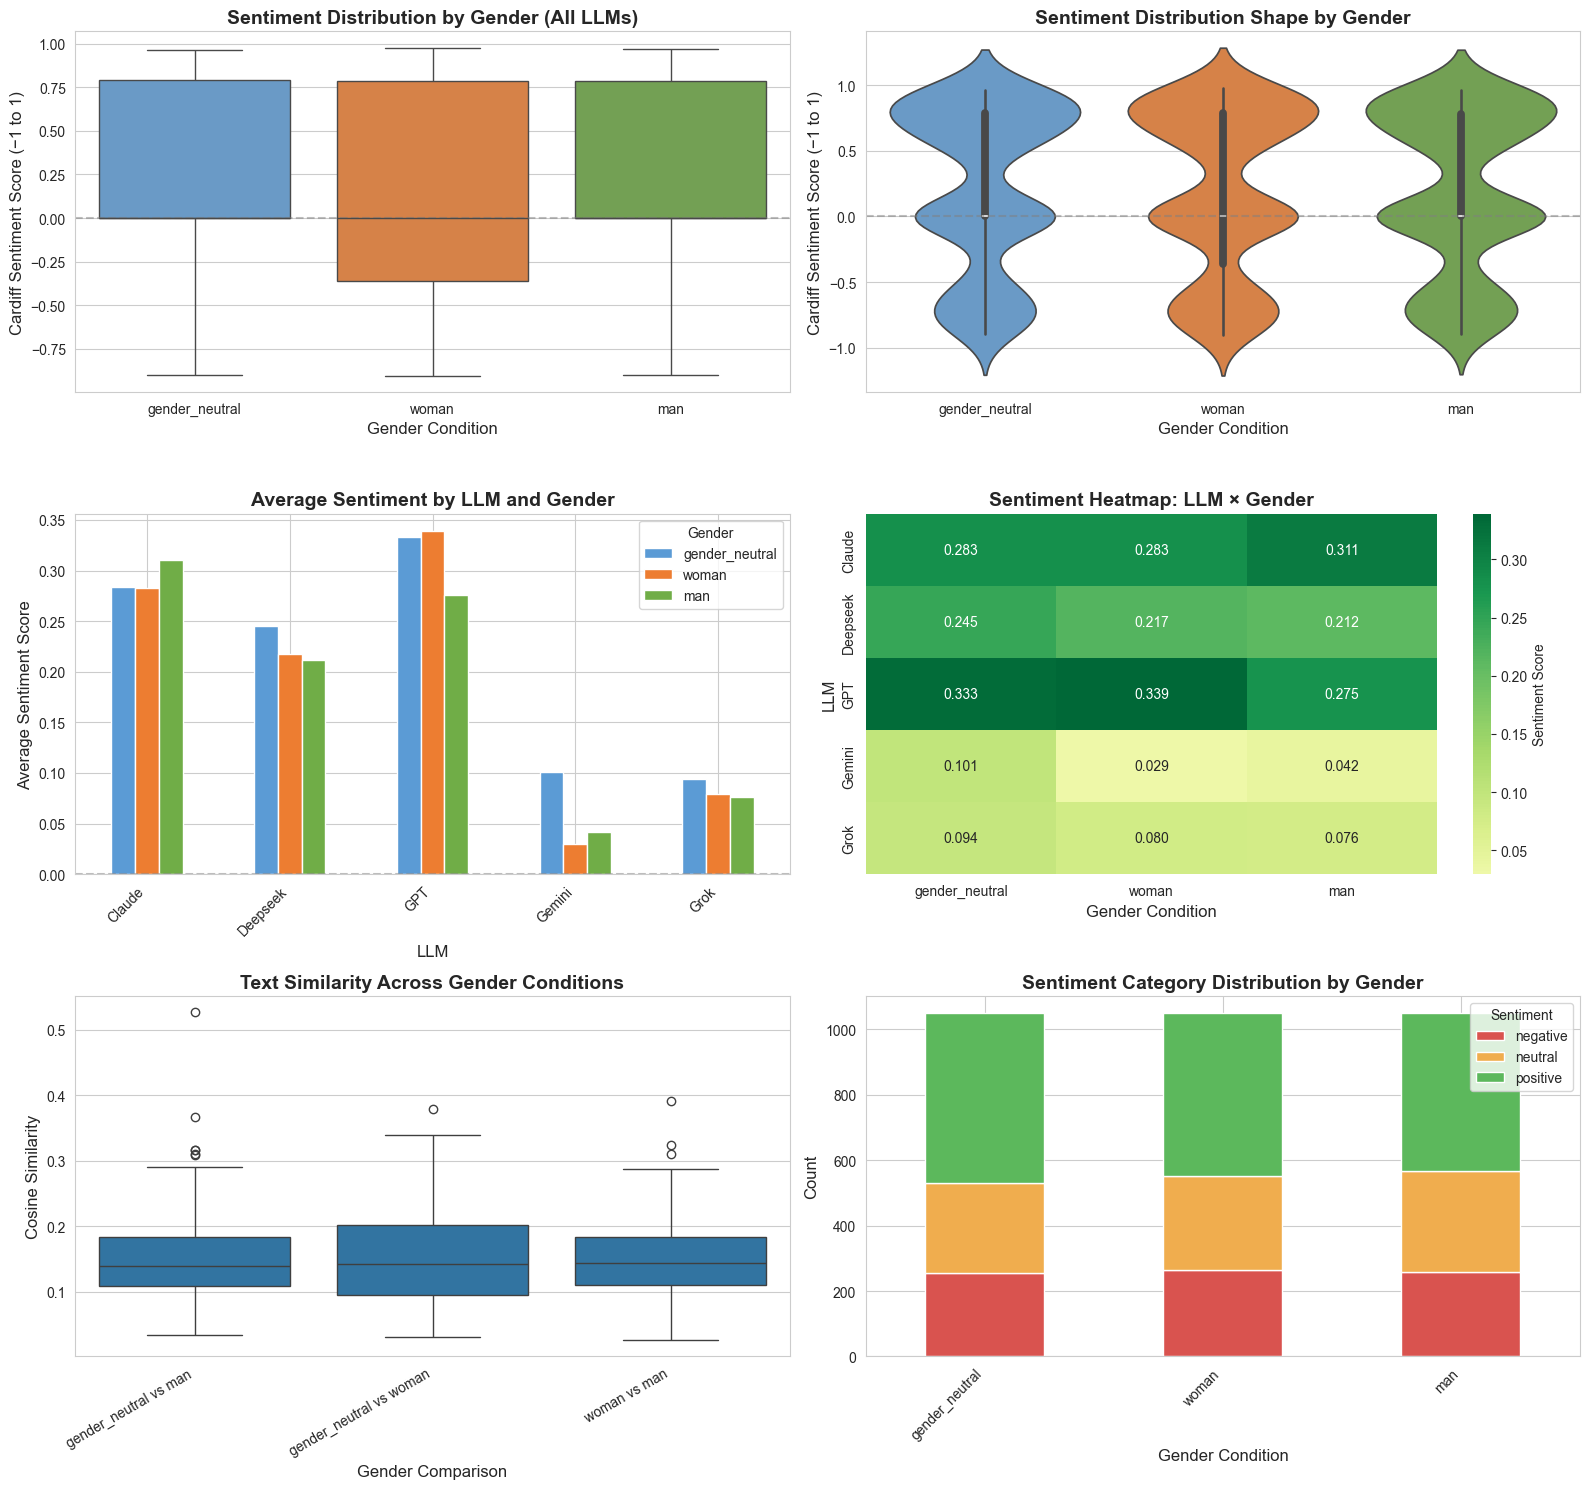

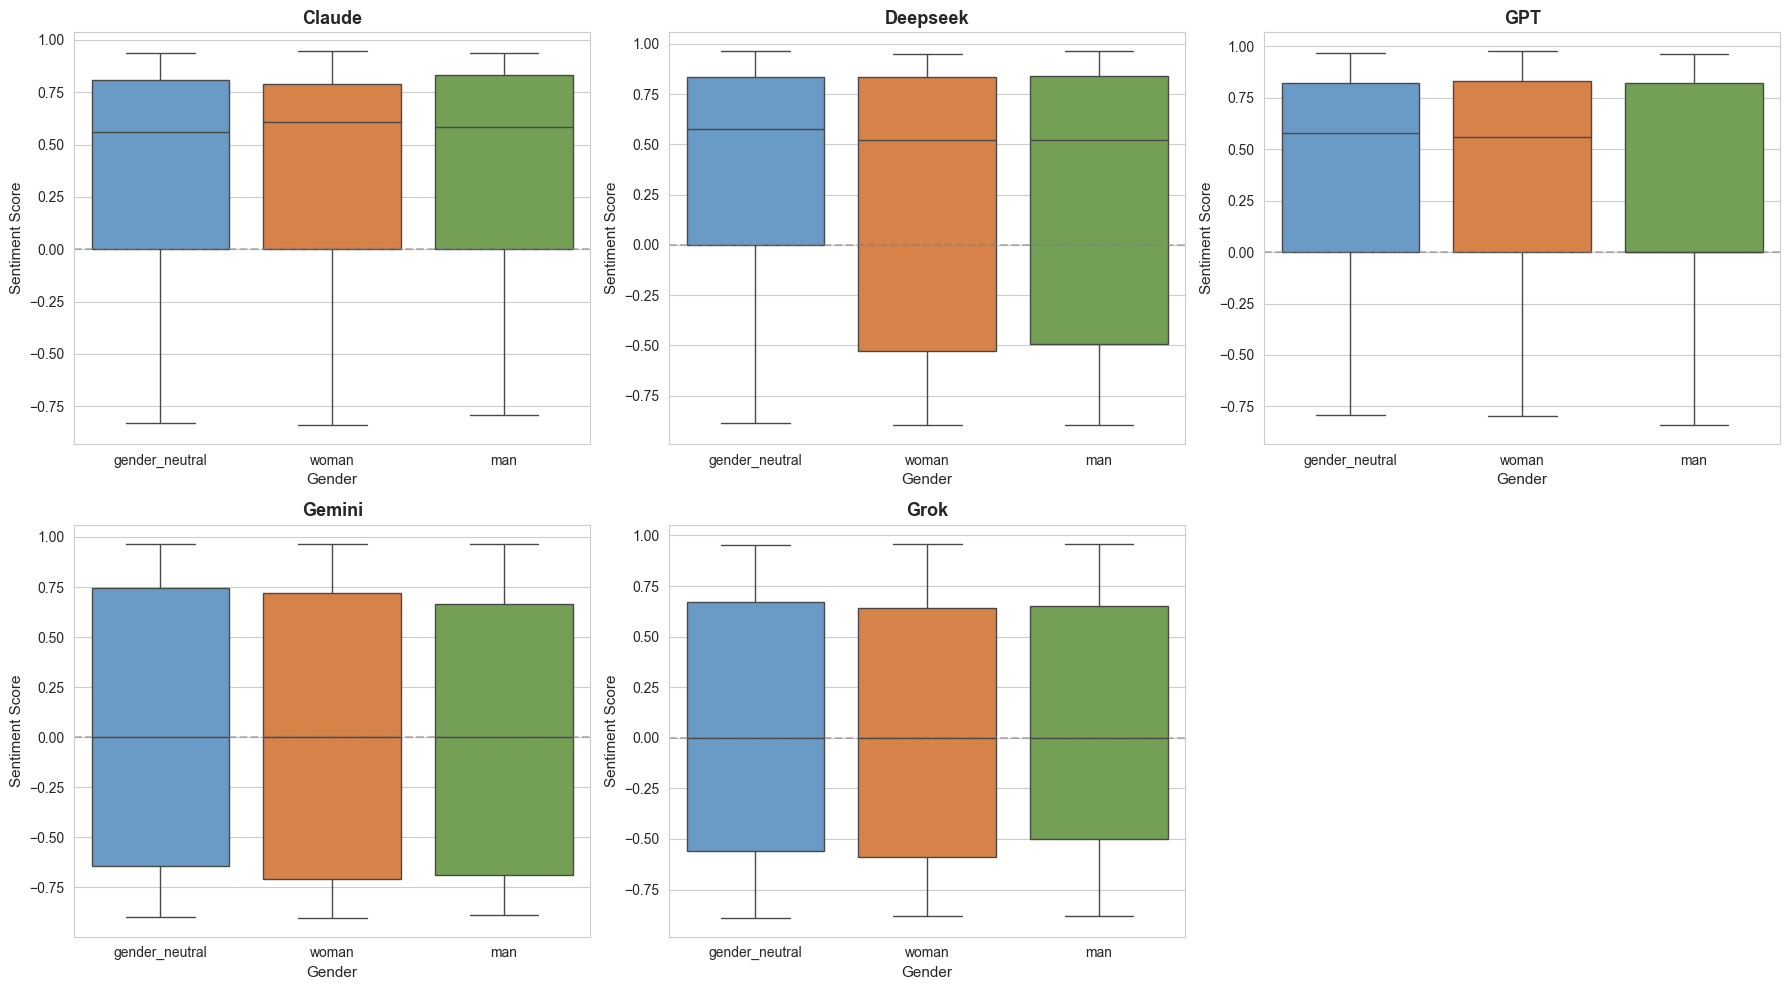

In [ ]:
# Create visualizations
create_visualizations(results_df, similarity_df)

# STEP 7: EXPORT RESULTS

In [ ]:
def export_results(results_df, similarity_df):
    """
    Export all results to CSV and text summary files.
    """
    print("\nExporting results...")

    # Full sentiment results
    results_df.to_csv('sentiment_analysis_cardiff_results.csv', index=False)
    print("  Saved: sentiment_analysis_cardiff_results.csv")

    # Gender summary
    gender_summary = results_df.groupby('Gender').agg(
        count=('cardiff_numerical', 'count'),
        mean=('cardiff_numerical', 'mean'),
        std=('cardiff_numerical', 'std'),
        min=('cardiff_numerical', 'min'),
        max=('cardiff_numerical', 'max')
    ).round(4)
    gender_summary.to_csv('sentiment_summary_by_gender.csv')
    print("  Saved: sentiment_summary_by_gender.csv")

    # LLM × Gender summary
    llm_gender_summary = results_df.groupby(['LLM', 'Gender']).agg(
        count=('cardiff_numerical', 'count'),
        mean=('cardiff_numerical', 'mean'),
        std=('cardiff_numerical', 'std')
    ).round(4)
    llm_gender_summary.to_csv('sentiment_summary_by_llm_gender.csv')
    print("  Saved: sentiment_summary_by_llm_gender.csv")

    # Cosine similarity results
    if len(similarity_df) > 0:
        similarity_df.to_csv('cosine_similarity_results.csv', index=False)
        print("  Saved: cosine_similarity_results.csv")

        sim_summary = similarity_df.groupby('Comparison').agg(
            count=('Cosine_Similarity', 'count'),
            mean=('Cosine_Similarity', 'mean'),
            std=('Cosine_Similarity', 'std'),
            min=('Cosine_Similarity', 'min'),
            max=('Cosine_Similarity', 'max')
        ).round(4)
        sim_summary.to_csv('cosine_similarity_summary.csv')
        print("  Saved: cosine_similarity_summary.csv")

    print("\nAll results exported!")


In [ ]:
# Export all results
export_results(results_df, similarity_df)


# FINAL SUMMARY

In [ ]:
print("ANALYSIS COMPLETE - SUMMARY")

print("\n1. SENTIMENT ANALYSIS (Cardiff RoBERTa)")
print(f"Total responses analyzed: {len(results_df)}")
print(f"\nSentiment by Gender:")
print(results_df.groupby('Gender')['cardiff_numerical']
      .agg(['count', 'mean', 'std']).round(4))

print("\n2. COSINE SIMILARITY (TF-IDF on Original Text)")
if len(similarity_df) > 0:
    print(f"Total pairwise comparisons: {len(similarity_df)}")
    print(f"\nMean Similarity by Comparison:")
    print(similarity_df.groupby('Comparison')['Cosine_Similarity']
          .agg(['count', 'mean']).round(4))
else:
    print("No similarity data available")

print("\n3. OUTPUT FILES GENERATED")
for f in ['sentiment_analysis_cardiff_results.csv',
          'sentiment_summary_by_gender.csv',
          'sentiment_summary_by_llm_gender.csv',
          'cosine_similarity_results.csv',
          'cosine_similarity_summary.csv',
          'sentiment_analysis_results.png',
          'sentiment_by_llm.png']:
    print(f"  {f}")


print("All analyses complete!")

